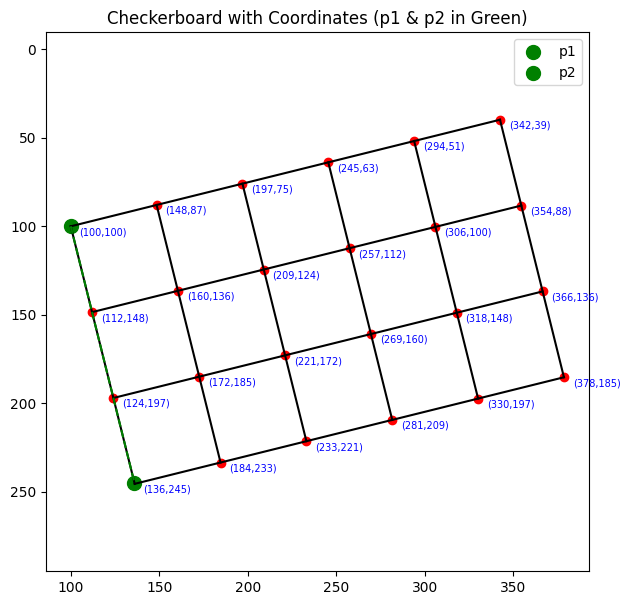

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_checkerboard_points(p1, p2, square_size, rows, cols):
    """
    Generate checkerboard points given p1 (top-left), 
    p2 (point directly below p1), and square size.
    """
    x1, y1 = p1
    x2, y2 = p2

    # Direction vector from p1 to p2 (vertical direction)
    v = np.array([x2 - x1, y2 - y1], dtype=float)
    v = v / np.linalg.norm(v) * square_size  # scale to one square size

    # Perpendicular vector (horizontal direction)
    h = np.array([v[1], -v[0]])  # rotate 90 degrees
    h = h / np.linalg.norm(h) * square_size

    points = []
    for r in range(rows):
        for c in range(cols):
            pt = np.array(p1, dtype=float) + r * v + c * h
            points.append(pt)
    return np.array(points, dtype=np.float32)

def visualize_checkerboard(points, rows, cols, p1, p2):
    """
    Visualize checkerboard points with coordinates.
    Highlight p1 and p2 in green.
    """
    plt.figure(figsize=(7, 7))

    # Draw all points
    for (x, y) in points:
        plt.scatter(x, y, c="red")
        plt.text(x+5, y+5, f"({int(x)},{int(y)})", fontsize=7, color="blue")

    # Draw grid lines
    points = points.reshape(rows, cols, 2)
    for r in range(rows):
        plt.plot(points[r,:,0], points[r,:,1], "k-")
    for c in range(cols):
        plt.plot(points[:,c,0], points[:,c,1], "k-")

    # Highlight p1 and p2
    plt.scatter(*p1, c="green", s=100, label="p1")
    plt.scatter(*p2, c="green", s=100, label="p2")
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], "g--")  # connect them

    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.legend()
    plt.title("Checkerboard with Coordinates (p1 & p2 in Green)")
    plt.show()

# Example usage
p1 = (100, 100)  
p2 = (136, 245)  
square_size = 50  
rows, cols = 4, 6  

points = generate_checkerboard_points(p1, p2, square_size, rows, cols)
visualize_checkerboard(points, rows, cols, p1, p2)


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load image ---
img = cv2.imread("./camera1/External_calibration_images/192.168.20.101_01_20250729102919137.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- Define checkerboard pattern (number of inner corners, not squares!) ---
rows, cols = 5, 7   # adjust to your checkerboard
pattern_size = (cols, rows)

# --- Find corners ---
ret, corners = cv2.findChessboardCorners(gray, pattern_size, None)

if ret:
    # Refine corner positions to subpixel accuracy
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    corners = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)

    # Draw corners on image (for OpenCV visualization)
    img_vis = img.copy()
    cv2.drawChessboardCorners(img_vis, pattern_size, corners, ret)

    # Pick four extreme corners
    top_left     = corners[0][0]
    top_right    = corners[cols-1][0]
    bottom_left  = corners[(rows-1)*cols][0]
    bottom_right = corners[-1][0]
    center       = corners[(rows)//2][0] #np.mean([top_left, top_right, bottom_left, bottom_right], axis=0)

    # --- Visualization with matplotlib ---
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))

    # Mark corners
    for name, pt, color in [
        ("top-left", top_left, "green"),
        ("top-right", top_right, "red"),
        ("bottom-left", bottom_left, "blue"),
        ("bottom-right", bottom_right, "purple"),
        ("center", center, "yellow")
    ]:
        plt.scatter(pt[0], pt[1], s=120, c=color, label=name)
        plt.text(pt[0]+5, pt[1]+5, f"({int(pt[0])},{int(pt[1])})", fontsize=8, color=color)

    plt.axis("equal")
    plt.legend()
    plt.title("Detected Checkerboard Corners with Center")
    plt.show()

else:
    print("❌ Checkerboard not detected. Adjust rows/cols or image quality.")


[ WARN:0@0.004] global loadsave.cpp:275 findDecoder imread_('./camera1/External_calibration_images/192.168.20.101_01_20250729102919137.jpeg'): can't open/read file: check file path/integrity


error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [18]:
import numpy as np
import matplotlib.pyplot as plt

def predict_checkerboard_points(p1, p2, rows, cols, step=1, clockwise=False):
    """
    Predict inner-corner grid points when P1 and P2 define the same column (vertical direction).

    p1: (x, y) top point of the first column
    p2: (x, y) bottom point of the first column
    rows: number of inner corners vertically
    cols: number of inner corners horizontally
    step: number of squares between p1 and p2 (default=1)
    clockwise: if True, flip horizontal direction
    Returns:
        (rows*cols, 2) array of predicted [x, y] points (row-major order)
    """
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)

    # vertical direction
    v = p2 - p1
    
    d = np.linalg.norm(v)
    if d == 0:
        raise ValueError("p1 and p2 must be different points")

    # single-step vector vertically
    v_step = v / (rows - 1)

    # horizontal direction (perpendicular to vertical)
    h_step = np.array([v_step[1], -v_step[0]])
    if clockwise:
        h_step = -h_step

    # normalize h_step to same spacing as v_step
    h_step = h_step / np.linalg.norm(h_step) * np.linalg.norm(v_step)

    # build grid (row-major: top→bottom, left→right)
    grid = []
    for c in range(cols):
        offset = c * h_step
        for r in range(rows):
            grid.append(p1 + r * v_step + offset)

    return np.asarray(grid, dtype=np.float32)


P1 [-154.5   71. ]
P2 [-77.5  71. ]
P3 [-154.5   -63.75]
P4 [-77.5  -63.75]
P5 [-116.     13.25]


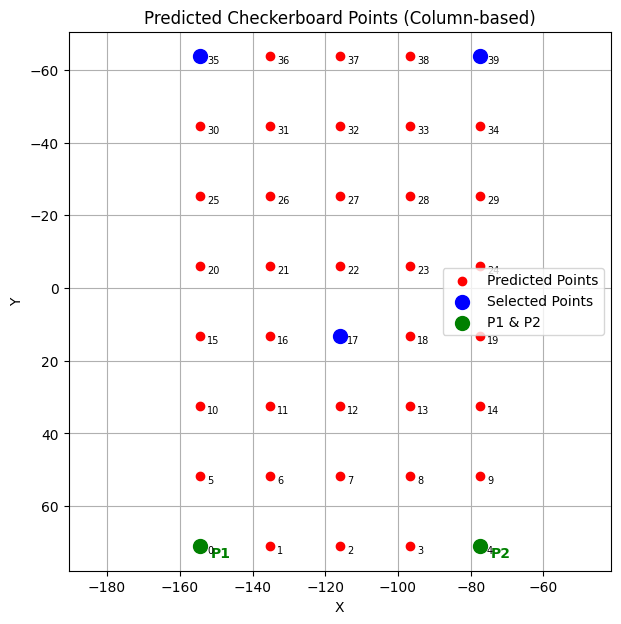

In [20]:
# --- Example ---
P1 = (-154.5, 71.0)   # top of column
P2 = (-77.5, 71.0)   # bottom of same column

rows, cols = 5, 8
pts = predict_checkerboard_points(P1, P2, rows, cols)

# --- Special indices to mark in blue ---
special_indices = [35, 39, 17]

# --- Plot result ---
plt.figure(figsize=(7, 7))

# Plot all predicted points (red)
plt.scatter(pts[:, 0], pts[:, 1], c='r', marker='o', label='Predicted Points')

# Highlight selected indices (blue)
plt.scatter(pts[special_indices, 0], pts[special_indices, 1],
            c='b', s=100, marker='o', label='Selected Points')

# Plot P1 and P2 (green)
plt.scatter([P1[0], P2[0]], [P1[1], P2[1]],
            c='g', s=100, marker='o', label='P1 & P2')
plt.text(P1[0] + 3, P1[1] + 3, "P1", color='green', fontsize=10, weight='bold')
plt.text(P2[0] + 3, P2[1] + 3, "P2", color='green', fontsize=10, weight='bold')

# Annotate all indices
for i, (x, y) in enumerate(pts):
    plt.text(x + 2, y + 2, str(i), fontsize=7, color='black')

lists= [0,4,35,39,17]
for id, i in enumerate(lists):
    print(f"P{id+1} {pts[i]}")

plt.gca().invert_yaxis()  # match OpenCV coordinate system
plt.title("Predicted Checkerboard Points (Column-based)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

[100. 200.]


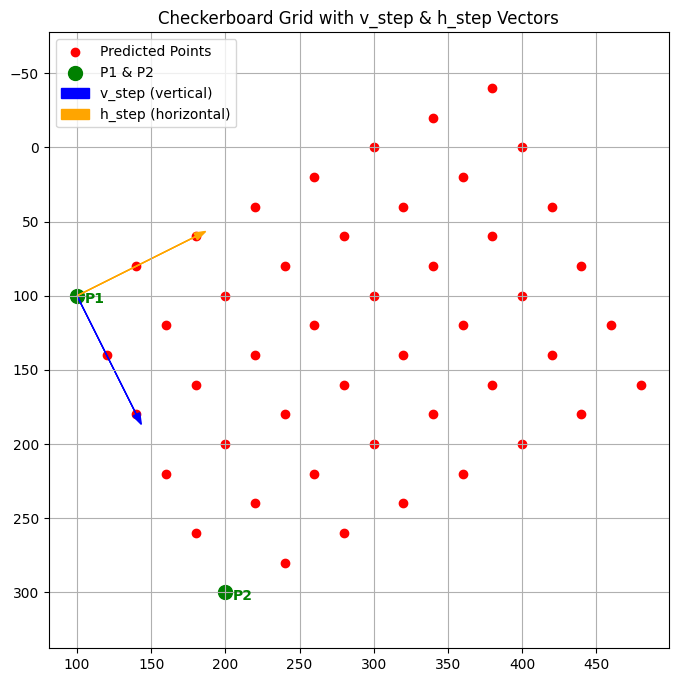

v_step (vertical vector): [20. 40.]
h_step (horizontal vector): [ 40. -20.]


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def predict_checkerboard_points(p1, p2, rows, cols, step=1, clockwise=False, visualize=False):
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)

    # vertical direction
    v = p2 - p1
    print(v)
    if np.allclose(v, 0):
        raise ValueError("p1 and p2 must be different points")

    # vertical step (downward direction)
    v_step = v / (rows - 1)

    # horizontal direction (perpendicular)
    h_step = np.array([v_step[1], -v_step[0]])
    if clockwise:
        h_step = -h_step

    # normalize horizontal step to same spacing
    h_step = h_step / np.linalg.norm(h_step) * np.linalg.norm(v_step)

    # build grid
    grid = []
    for c in range(cols):
        offset = c * h_step
        for r in range(rows):
            grid.append(p1 + r * v_step + offset)
    grid = np.asarray(grid, dtype=np.float32)

    # --- Visualization ---
    if visualize:
        plt.figure(figsize=(8, 8))
        plt.scatter(grid[:, 0], grid[:, 1], c='r', label='Predicted Points')

        # P1 & P2
        plt.scatter([p1[0], p2[0]], [p1[1], p2[1]], c='g', s=100, label='P1 & P2')
        plt.text(p1[0]+5, p1[1]+5, "P1", color='green', fontsize=10, weight='bold')
        plt.text(p2[0]+5, p2[1]+5, "P2", color='green', fontsize=10, weight='bold')

        # Plot v_step and h_step as arrows
        origin = p1
        plt.arrow(origin[0], origin[1], v_step[0]*2, v_step[1]*2, 
                  head_width=5, color='blue', label='v_step (vertical)')
        plt.arrow(origin[0], origin[1], h_step[0]*2, h_step[1]*2, 
                  head_width=5, color='orange', label='h_step (horizontal)')

        plt.gca().invert_yaxis()  # match OpenCV coordinate system
        plt.axis('equal')
        plt.grid(True)
        plt.legend()
        plt.title("Checkerboard Grid with v_step & h_step Vectors")
        plt.show()

    return grid, v_step, h_step


# --- Example usage ---
P1 = (100.0, 100.0)   # top of column
P2 = (200, 300.0)   # bottom of column

rows, cols = 6, 8
pts, v_step, h_step = predict_checkerboard_points(P1, P2, rows, cols, visualize=True)

print("v_step (vertical vector):", v_step)
print("h_step (horizontal vector):", h_step)


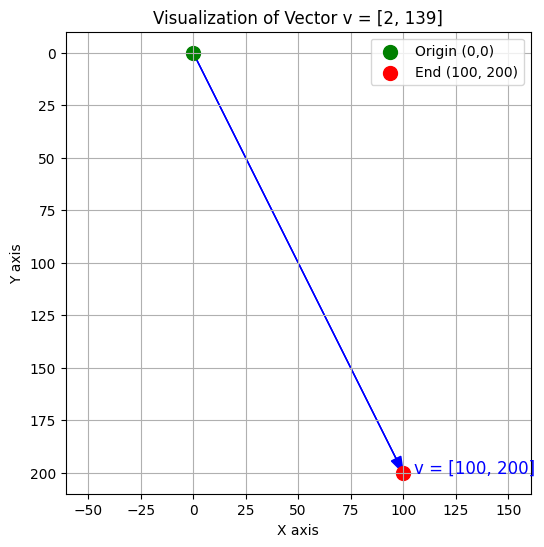

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define vector
v = np.array([100, 200])

# Create plot
plt.figure(figsize=(6, 6))

# Draw vector as an arrow
plt.arrow(0, 0, v[0], v[1], head_width=5, color='blue', length_includes_head=True)

# Annotate start and end
plt.scatter(0, 0, c='green', s=100, label='Origin (0,0)')
plt.scatter(v[0], v[1], c='red', s=100, label=f'End ({v[0]}, {v[1]})')
plt.text(v[0] + 5, v[1], f'v = [{v[0]}, {v[1]}]', color='blue', fontsize=12)

# Add axis labels and grid
plt.title("Visualization of Vector v = [2, 139]")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.grid(True)
plt.axis('equal')

# Invert Y axis to match OpenCV coordinate system
plt.gca().invert_yaxis()

plt.legend()
plt.show()


P1 [100. 100.]
P2 [214.28571429 100.        ]
P3 [185.71428571 -14.28571429]
P4 [300.         -14.28571429]
P5 [128.57142857  42.85714286]


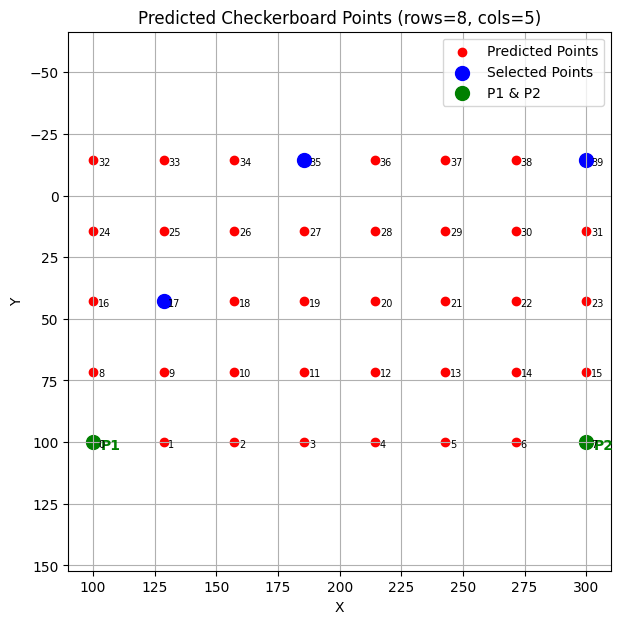

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def predict_checkerboard_points(p1, p2, rows, cols, step=1, clockwise=False):
    """
    Predict inner-corner grid points for a checkerboard pattern.
    p1: (x, y) top point of the first column
    p2: (x, y) bottom point of the same column
    rows: number of inner corners vertically
    cols: number of inner corners horizontally
    step: number of squares between p1 and p2 (default=1)
    clockwise: if True, flip horizontal direction
    Returns: (rows * cols, 2) NumPy array of [x, y] points
    """
    p1 = np.array(p1, dtype=float)
    p2 = np.array(p2, dtype=float)

    # vertical direction vector (down)
    v = p2 - p1
    if np.linalg.norm(v) == 0:
        raise ValueError("p1 and p2 must be different points")

    v_unit = v / np.linalg.norm(v)
    step_v = np.linalg.norm(v) / (rows - 1)  # distance between row corners

    # horizontal direction (perpendicular to v)
    h_unit = np.array([v_unit[1], -v_unit[0]])  # rotate 90° clockwise
    if clockwise:
        h_unit = -h_unit

    step_h = step_v  # assume square cells

    points = []
    for c in range(cols):
        for r in range(rows):
            pt = p1 + v_unit * (r * step_v) + h_unit * (c * step_h)
            points.append(pt)

    return np.array(points)

# --- Example ---
P1 = (100, 100.0)   # top of column
P2 = (300, 100.0)   # bottom of same column

rows, cols = 8, 5
pts = predict_checkerboard_points(P1, P2, rows, cols)

# --- Special indices to mark in blue ---
special_indices = [35, 39, 17]

# --- Plot result ---
plt.figure(figsize=(7, 7))

# Plot all predicted points (red)
plt.scatter(pts[:, 0], pts[:, 1], c='r', marker='o', label='Predicted Points')

# Highlight selected indices (blue)
plt.scatter(pts[special_indices, 0], pts[special_indices, 1],
            c='b', s=100, marker='o', label='Selected Points')

# Plot P1 and P2 (green)
plt.scatter([P1[0], P2[0]], [P1[1], P2[1]],
            c='g', s=100, marker='o', label='P1 & P2')
plt.text(P1[0] + 3, P1[1] + 3, "P1", color='green', fontsize=10, weight='bold')
plt.text(P2[0] + 3, P2[1] + 3, "P2", color='green', fontsize=10, weight='bold')

# Annotate all indices
for i, (x, y) in enumerate(pts):
    plt.text(x + 2, y + 2, str(i), fontsize=7, color='black')

lists = [0, 4, 35, 39, 17]
for id, i in enumerate(lists):
    print(f"P{id+1} {pts[i]}")

plt.gca().invert_yaxis()  # match OpenCV coordinate system
plt.title("Predicted Checkerboard Points (rows=8, cols=5)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


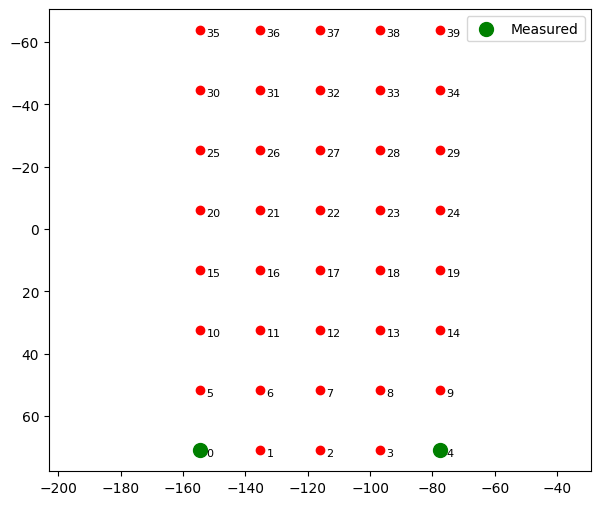

P1 [-154.5   71. ]
P2 [-77.5  71. ]
P3 [-154.5   -63.75]
P4 [-77.5  -63.75]
P5 [-116.     13.25]


In [ ]:
import numpy as np

def predict_checkerboard_points(
    bottom_left, bottom_right,
    cols=5, rows=8,
    aspect_ratio=1.0
):
    """
    Predicts inner-corner image coordinates for a checkerboard with shape (cols x rows)
    given only the two endpoints of the BOTTOM row: bottom_left and bottom_right.
    
    Assumptions:
      - Bottom row is visible and you clicked its two endpoints.
      - Squares are roughly square in the image (weak perspective).
      - 'cols' and 'rows' are INNER-corner counts (OpenCV convention).
        e.g., 5x8 means 5 corners across the bottom row, 8 rows of corners total.
      - aspect_ratio = (vertical spacing) / (horizontal spacing).
        Keep at 1.0 if you didn’t measure square height vs width in the image.

    Returns:
      pts: (rows, cols, 2) array of (x, y) image coordinates for each inner corner.
           pts[0, :] is the bottom row (left→right),
           pts[-1, :] is the top row.
    """
    bl = np.array(bottom_left, dtype=float)
    br = np.array(bottom_right, dtype=float)

    # Horizontal step along the bottom edge
    if cols < 2:
        raise ValueError("cols must be >= 2")
    hvec = (br - bl) / (cols - 1)  # per-column step along bottom

    # Estimate vertical step as a perpendicular to the bottom edge,
    # with magnitude ~= horizontal step * aspect_ratio
    # Perp rotate (dx,dy)->(-dy,dx)
    perp = np.array([-hvec[1], hvec[0]])
    if np.linalg.norm(perp) < 1e-9:
        raise ValueError("Bottom points are degenerate")
    perp = perp / np.linalg.norm(perp)

    # vertical step length
    vstep_len = np.linalg.norm(hvec) * aspect_ratio
    vvec = perp * vstep_len  # default: go "up" relative to bottom edge

    # Build grid by moving across columns, then stepping upward for rows
    pts = np.zeros((rows, cols, 2), dtype=float)

    # Bottom row (row 0)
    for c in range(cols):
        pts[0, c] = bl + c * hvec

    # Higher rows
    for r in range(1, rows):
        pts[r, :] = pts[0, :] + r * vvec

    # Heuristic: if the “up” direction points the wrong way (grid goes below bottom),
    # flip it to keep rows going visually upward (smaller y in most image coords).
    # Comment this out if your image coordinate system is different.
    if rows >= 2 and pts[1, 0][1] > pts[0, 0][1]:
        for r in range(1, rows):
            pts[r, :] = pts[0, :] - r * vvec

    return pts

# --- Example usage (replace with your measured points) ---
# bottom_left  = (x1, y1)
# bottom_right = (x2, y2)
# pts = predict_checkerboard_points(bottom_left, bottom_right, cols=5, rows=8, aspect_ratio=1.0)
# print(pts.shape)  # (8, 5,


Checkerboard Configuration:
Total width: 77.0 units
Square size: 15.4 × 15.4 units
Grid size: 6 columns × 9 rows = 54 points

Point[0][0] = (-154.50,   71.00)
Point[0][1] = (-139.10,   71.00)
Point[0][2] = (-123.70,   71.00)
Point[0][3] = (-108.30,   71.00)
Point[0][4] = ( -92.90,   71.00)
Point[0][5] = ( -77.50,   71.00)

Point[1][0] = (-154.50,   86.40)
Point[1][1] = (-139.10,   86.40)
Point[1][2] = (-123.70,   86.40)
Point[1][3] = (-108.30,   86.40)
Point[1][4] = ( -92.90,   86.40)
Point[1][5] = ( -77.50,   86.40)

Point[2][0] = (-154.50,  101.80)
Point[2][1] = (-139.10,  101.80)
Point[2][2] = (-123.70,  101.80)
Point[2][3] = (-108.30,  101.80)
Point[2][4] = ( -92.90,  101.80)
Point[2][5] = ( -77.50,  101.80)

Point[3][0] = (-154.50,  117.20)
Point[3][1] = (-139.10,  117.20)
Point[3][2] = (-123.70,  117.20)
Point[3][3] = (-108.30,  117.20)
Point[3][4] = ( -92.90,  117.20)
Point[3][5] = ( -77.50,  117.20)

Point[4][0] = (-154.50,  132.60)
Point[4][1] = (-139.10,  132.60)
Point[4][2] 

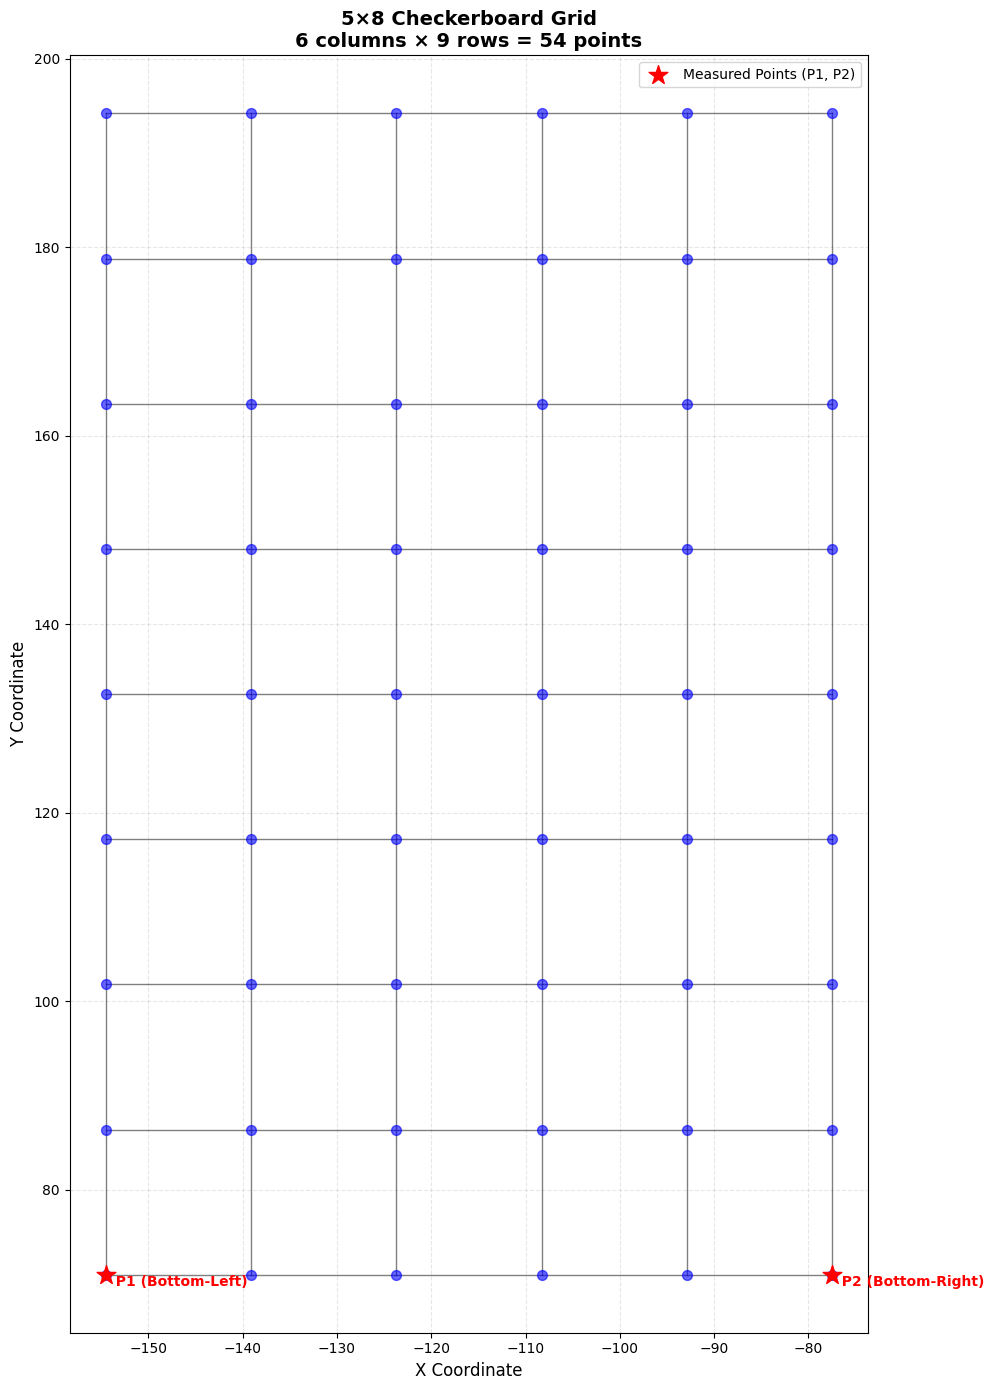


Total points calculated: 54

Corners:
Bottom-left:  (-154.50, 71.00)
Bottom-right: (-77.50, 71.00)
Top-left:     (-154.50, 194.20)
Top-right:    (-77.50, 194.20)


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Given points (bottom edge)
P1 = np.array([-154.5, 71.0])  # Bottom-left corner
P2 = np.array([-77.5, 71.0])   # Bottom-right corner

# Checkerboard dimensions
cols = 6  # 5 squares wide = 6 vertical lines
rows = 9  # 8 squares tall = 9 horizontal lines

# Calculate square dimensions
width = P2[0] - P1[0]  # Total width
square_width = width / 5  # Width of each square
square_height = square_width  # Assuming square checkerboard squares

print(f"Checkerboard Configuration:")
print(f"Total width: {width} units")
print(f"Square size: {square_width} × {square_height} units")
print(f"Grid size: {cols} columns × {rows} rows = {cols * rows} points")
print("\n" + "="*60)

# Generate all points
points = []
x_coords = []
y_coords = []

for row in range(rows):
    for col in range(cols):
        x = P1[0] + col * square_width
        y = P1[1] + row * square_height
        points.append((x, y))
        x_coords.append(x)
        y_coords.append(y)
        print(f"Point[{row}][{col}] = ({x:7.2f}, {y:7.2f})")
    print()

# Create visualization
fig, ax = plt.subplots(figsize=(10, 14))

# Plot all grid points
ax.scatter(x_coords, y_coords, c='blue', s=50, zorder=3, alpha=0.6)

# Draw vertical lines
for col in range(cols):
    x = P1[0] + col * square_width
    ax.plot([x, x], [P1[1], P1[1] + (rows-1) * square_height], 
            'k-', linewidth=1, alpha=0.5)

# Draw horizontal lines
for row in range(rows):
    y = P1[1] + row * square_height
    ax.plot([P1[0], P2[0]], [y, y], 
            'k-', linewidth=1, alpha=0.5)

# Highlight the two measured points
ax.scatter([P1[0], P2[0]], [P1[1], P1[1]], 
           c='red', s=200, marker='*', zorder=4, 
           label='Measured Points (P1, P2)')

# Add corner labels
ax.text(P1[0], P1[1], '  P1 (Bottom-Left)', 
        fontsize=10, ha='left', va='top', color='red', fontweight='bold')
ax.text(P2[0], P1[1], '  P2 (Bottom-Right)', 
        fontsize=10, ha='left', va='top', color='red', fontweight='bold')

# Formatting
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)
ax.set_title(f'5×8 Checkerboard Grid\n{cols} columns × {rows} rows = {len(points)} points', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"Total points calculated: {len(points)}")
print(f"\nCorners:")
print(f"Bottom-left:  ({points[0][0]:.2f}, {points[0][1]:.2f})")
print(f"Bottom-right: ({points[cols-1][0]:.2f}, {points[cols-1][1]:.2f})")
print(f"Top-left:     ({points[-cols][0]:.2f}, {points[-cols][1]:.2f})")
print(f"Top-right:    ({points[-1][0]:.2f}, {points[-1][1]:.2f})")

Checkerboard Configuration:
Total width: 77.0 units
Square size: 19.25 × 19.25 units
Grid size: 5 columns × 8 rows = 40 points

Point[0][0] = (-154.50,   71.00)
Point[0][1] = (-135.25,   71.00)
Point[0][2] = (-116.00,   71.00)
Point[0][3] = ( -96.75,   71.00)
Point[0][4] = ( -77.50,   71.00)

Point[1][0] = (-154.50,   90.25)
Point[1][1] = (-135.25,   90.25)
Point[1][2] = (-116.00,   90.25)
Point[1][3] = ( -96.75,   90.25)
Point[1][4] = ( -77.50,   90.25)

Point[2][0] = (-154.50,  109.50)
Point[2][1] = (-135.25,  109.50)
Point[2][2] = (-116.00,  109.50)
Point[2][3] = ( -96.75,  109.50)
Point[2][4] = ( -77.50,  109.50)

Point[3][0] = (-154.50,  128.75)
Point[3][1] = (-135.25,  128.75)
Point[3][2] = (-116.00,  128.75)
Point[3][3] = ( -96.75,  128.75)
Point[3][4] = ( -77.50,  128.75)

Point[4][0] = (-154.50,  148.00)
Point[4][1] = (-135.25,  148.00)
Point[4][2] = (-116.00,  148.00)
Point[4][3] = ( -96.75,  148.00)
Point[4][4] = ( -77.50,  148.00)

Point[5][0] = (-154.50,  167.25)
Point[5][

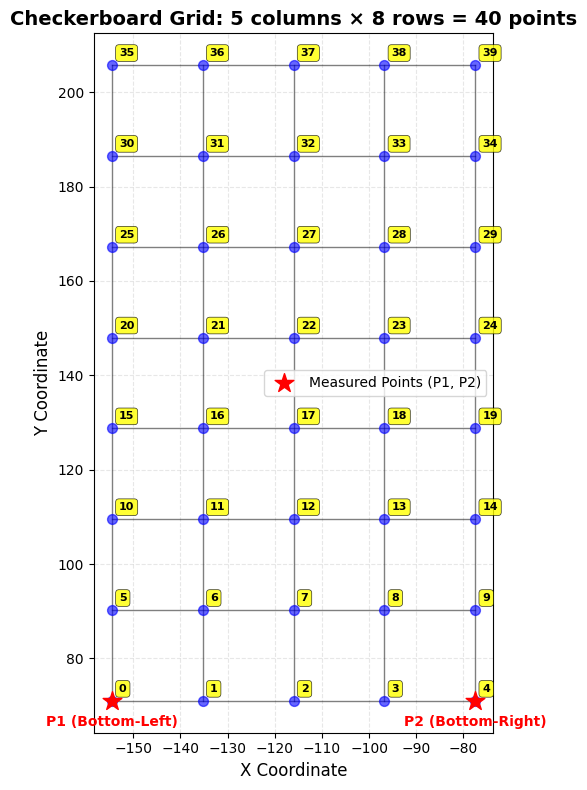


Total points calculated: 40

Corners:
Bottom-left:  (-154.50, 71.00)
Bottom-right: (-77.50, 71.00)
Top-left:     (-154.50, 205.75)
Top-right:    (-77.50, 205.75)


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Given points (bottom edge)
P1 = np.array([-154.5, 71.0])  # Bottom-left corner
P2 = np.array([-77.5, 71.0])   # Bottom-right corner

# Checkerboard dimensions
cols = 5  # 8 columns
rows = 8  # 5 rows

# Calculate square dimensions
width = P2[0] - P1[0]  # Total width
square_width = width / (cols - 1)  # Width of each square
square_height = square_width  # Assuming square checkerboard squares

print(f"Checkerboard Configuration:")
print(f"Total width: {width} units")
print(f"Square size: {square_width:.2f} × {square_height:.2f} units")
print(f"Grid size: {cols} columns × {rows} rows = {cols * rows} points")
print("\n" + "="*60)

# Generate all points
points = []
x_coords = []
y_coords = []

for row in range(rows):
    for col in range(cols):
        x = P1[0] + col * square_width
        y = P1[1] + row * square_height
        points.append((x, y))
        x_coords.append(x)
        y_coords.append(y)
        print(f"Point[{row}][{col}] = ({x:7.2f}, {y:7.2f})")
    print()

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Plot all grid points
ax.scatter(x_coords, y_coords, c='blue', s=50, zorder=3, alpha=0.6)

# Add point labels for all points
point_idx = 0
for row in range(rows):
    for col in range(cols):
        x = P1[0] + col * square_width
        y = P1[1] + row * square_height
        ax.text(x + 1.5, y + 1.5, f'{point_idx}', 
                fontsize=8, ha='left', va='bottom', 
                color='black', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', edgecolor='black', linewidth=0.5, alpha=0.8))
        point_idx += 1

# Draw vertical lines
for col in range(cols):
    x = P1[0] + col * square_width
    ax.plot([x, x], [P1[1], P1[1] + (rows-1) * square_height], 
            'k-', linewidth=1, alpha=0.5)

# Draw horizontal lines
for row in range(rows):
    y = P1[1] + row * square_height
    ax.plot([P1[0], P2[0]], [y, y], 
            'k-', linewidth=1, alpha=0.5)

# Highlight the two measured points
ax.scatter([P1[0], P2[0]], [P1[1], P1[1]], 
           c='red', s=200, marker='*', zorder=4, 
           label='Measured Points (P1, P2)')

# Add corner labels
ax.text(P1[0], P1[1]-3, 'P1 (Bottom-Left)', 
        fontsize=10, ha='center', va='top', color='red', fontweight='bold')
ax.text(P2[0], P1[1]-3, 'P2 (Bottom-Right)', 
        fontsize=10, ha='center', va='top', color='red', fontweight='bold')

# Formatting
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)
ax.set_title(f'Checkerboard Grid: {cols} columns × {rows} rows = {len(points)} points', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"Total points calculated: {len(points)}")
print(f"\nCorners:")
print(f"Bottom-left:  ({points[0][0]:.2f}, {points[0][1]:.2f})")
print(f"Bottom-right: ({points[cols-1][0]:.2f}, {points[cols-1][1]:.2f})")
print(f"Top-left:     ({points[-cols][0]:.2f}, {points[-cols][1]:.2f})")
print(f"Top-right:    ({points[-1][0]:.2f}, {points[-1][1]:.2f})")